In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)

In [3]:
df = pd.read_csv("C:\\Users\\sonim\\Desktop\\CUSTOMER SEGMENTATION\\DATA\\RAW\\processed_data.csv")

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [6]:
df["InvoiceDate"].max()

Timestamp('2010-12-09 20:01:00')

In [7]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2010-12-10 20:01:00


In [8]:
recency = (
    df.groupby("Customer ID")["InvoiceDate"]
      .max()
)

In [9]:
print(recency)

Customer ID
12346.0   2010-06-28 13:53:00
12347.0   2010-12-07 14:57:00
12348.0   2010-09-27 14:59:00
12349.0   2010-10-28 08:23:00
12351.0   2010-11-29 15:23:00
                  ...        
18283.0   2010-11-22 15:30:00
18284.0   2010-10-04 11:33:00
18285.0   2010-02-17 10:24:00
18286.0   2010-08-20 11:57:00
18287.0   2010-11-22 11:51:00
Name: InvoiceDate, Length: 4312, dtype: datetime64[ns]


In [10]:
recency = (
    reference_date
    - df.groupby("Customer ID")["InvoiceDate"].max()
).dt.days

In [11]:
print(recency)

Customer ID
12346.0    165
12347.0      3
12348.0     74
12349.0     43
12351.0     11
          ... 
18283.0     18
18284.0     67
18285.0    296
18286.0    112
18287.0     18
Name: InvoiceDate, Length: 4312, dtype: int64


In [12]:
frequency = (
    df.groupby("Customer ID")["Invoice"]
      .nunique()
)

In [13]:
print(frequency)

Customer ID
12346.0    11
12347.0     2
12348.0     1
12349.0     3
12351.0     1
           ..
18283.0     6
18284.0     1
18285.0     1
18286.0     2
18287.0     4
Name: Invoice, Length: 4312, dtype: int64


In [14]:
monetary = (
    df.groupby("Customer ID")["TotalPrice"]
      .sum()
)

In [15]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [16]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


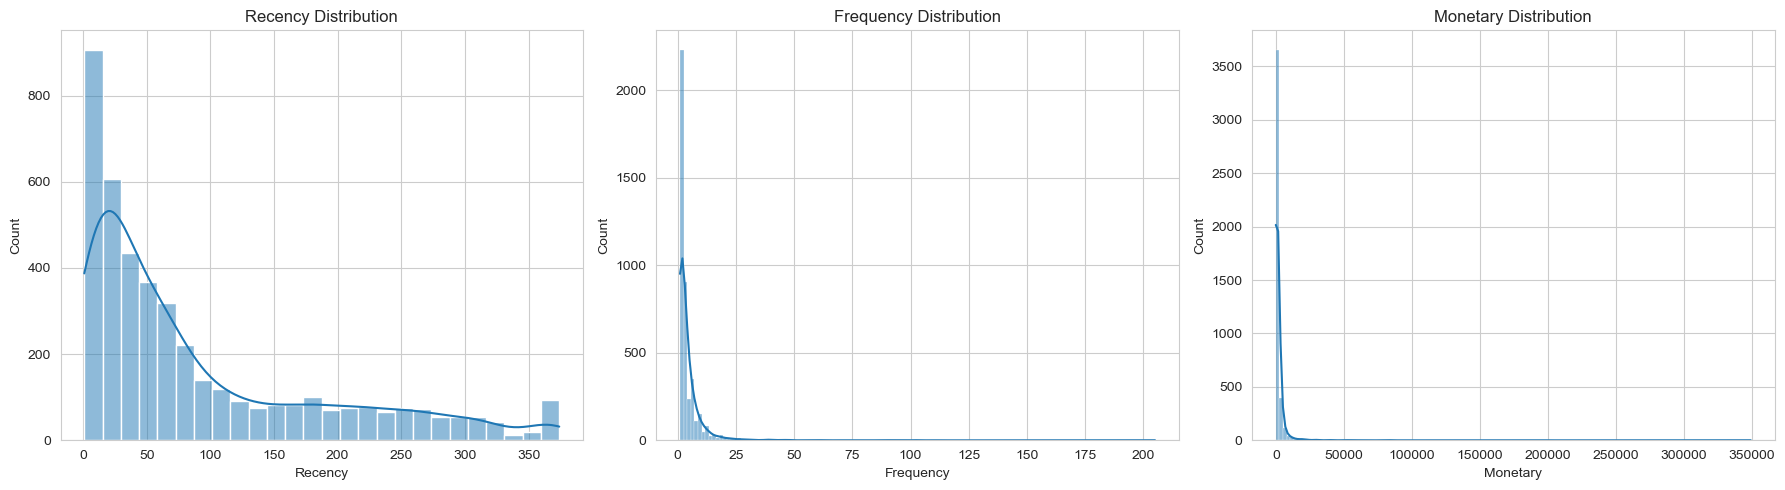

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [18]:
rfm_log = np.log1p(rfm)

In [19]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,3.856070,1.371142,6.608946
std,1.299920,0.690565,1.281153
min,0.693147,0.693147,1.373716
25%,2.944439,0.693147,5.730708
50%,3.988984,1.098612,6.554809
75%,4.919981,1.791759,7.447711
max,5.926926,5.327876,12.763301


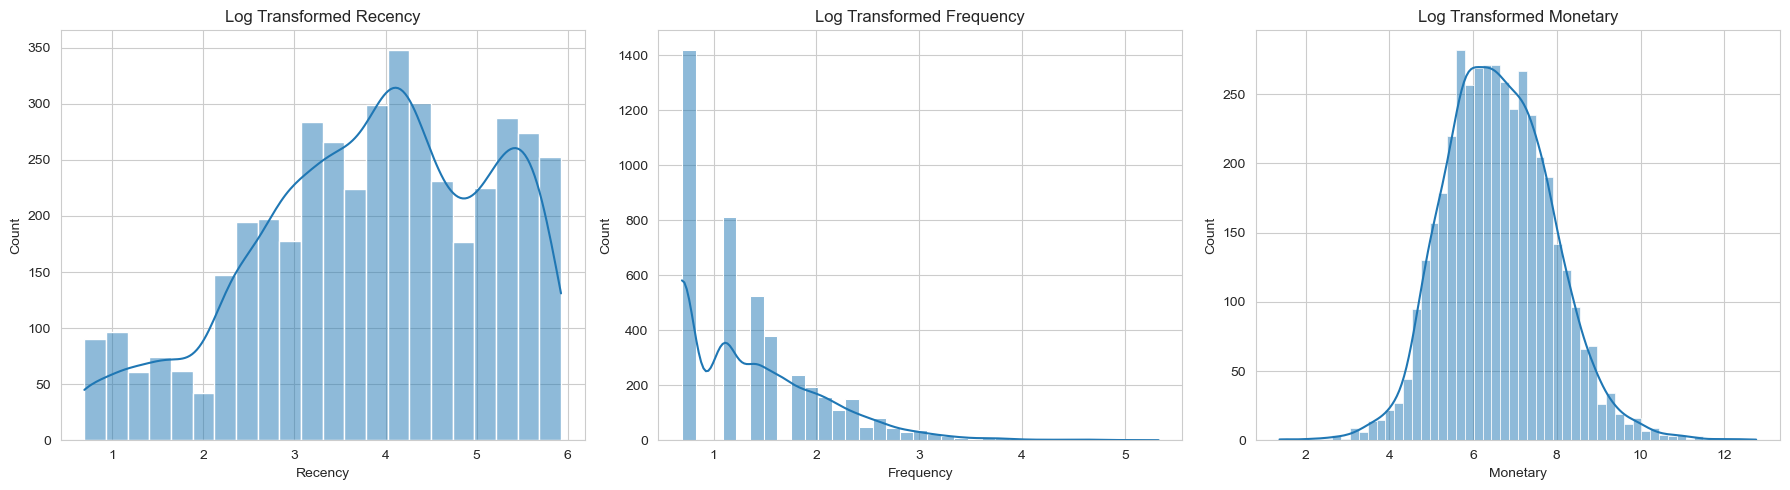

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_log["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Log Transformed Recency")

sns.histplot(rfm_log["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Log Transformed Frequency")

sns.histplot(rfm_log["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Log Transformed Monetary")

plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

In [22]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,4312.00,4312.00,4312.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-2.43,-0.98,-4.09
25%,-0.70,-0.98,-0.69
50%,0.10,-0.39,-0.04
75%,0.82,0.61,0.65
max,1.59,5.73,4.80


In [26]:
rfm_scaled.to_csv("../DATA/RAW/processed/rfm_features.csv", index=True)

In [27]:
rfm_scaled.head()
rfm_scaled.info()
rfm_scaled.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 4312 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4312 non-null   float64
 1   Frequency  4312 non-null   float64
 2   Monetary   4312 non-null   float64
dtypes: float64(3)
memory usage: 134.8 KB


,Recency,Frequency,Monetary
count,4.312000e+03,4.312000e+03,4.312000e+03
mean,-9.063045e-17,6.385327e-17,2.372870e-16
std,1.000116e+00,1.000116e+00,1.000116e+00
min,-2.433450e+00,-9.819103e-01,-4.086817e+00
25%,-7.013791e-01,-9.819103e-01,-6.855851e-01
50%,1.022598e-01,-3.946928e-01,-4.226108e-02
75%,8.185384e-01,6.091622e-01,6.547718e-01
max,1.593249e+00,5.730367e+00,4.804321e+00


In [30]:
rfm.to_csv(
    "../DATA/RAW/processed/rfm_original.csv",
    index=True
)